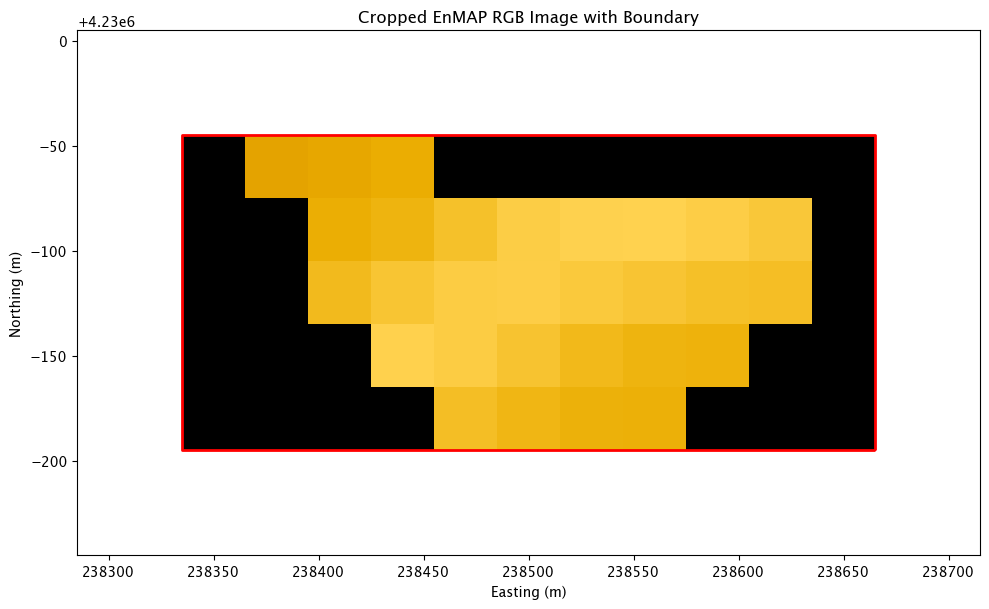

In [4]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box

# --- Load your cropped EnMAP image ---
enmap_path = "/Users/dangause/Desktop/calacademy/hrs_botany/rs-hsi-botany/notebooks/downloads/enmap_downloads_20250626/0080/ENMAP01-____L2A-DT0000028166_20230709T064108Z_002_V010402_20240724T202501Z-SPECTRAL_IMAGE_COG.tiff"

with rasterio.open(enmap_path) as src:
    image = src.read()  # shape: (bands, height, width)
    transform = src.transform
    enmap_crs = src.crs
    height, width = src.height, src.width

# --- Stretch RGB bands for display ---
def stretch_rgb(rgb):
    vmin, vmax = np.percentile(rgb[rgb > -32768], [2, 98])
    return np.clip((rgb - vmin) / (vmax - vmin), 0, 1)

rgb_image = image[[44, 28, 9], :, :]  # R=45, G=29, B=10 (zero-based)
rgb_stretched = stretch_rgb(rgb_image)
rgb_plot = np.transpose(rgb_stretched, (1, 2, 0))  # shape: (H, W, 3)

# --- Create boundary GeoDataFrame from raster extent ---
xmin = transform.c
xmax = xmin + transform.a * width
ymax = transform.f
ymin = ymax + transform.e * height

bbox = box(xmin, ymin, xmax, ymax)
gdf_boundary = gpd.GeoDataFrame(geometry=[bbox], crs=enmap_crs)

# --- Plot image and boundary box ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb_plot, extent=[xmin, xmax, ymin, ymax], origin="upper")

# Plot EnMAP boundary
gdf_boundary.boundary.plot(ax=ax, color="red", linewidth=2)

# Zoom to extent with buffer
buffer = 50  # meters
x0, y0, x1, y1 = gdf_boundary.total_bounds
ax.set_xlim(x0 - buffer, x1 + buffer)
ax.set_ylim(y0 - buffer, y1 + buffer)

# Final formatting
ax.set_title("Cropped EnMAP RGB Image with Boundary")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()


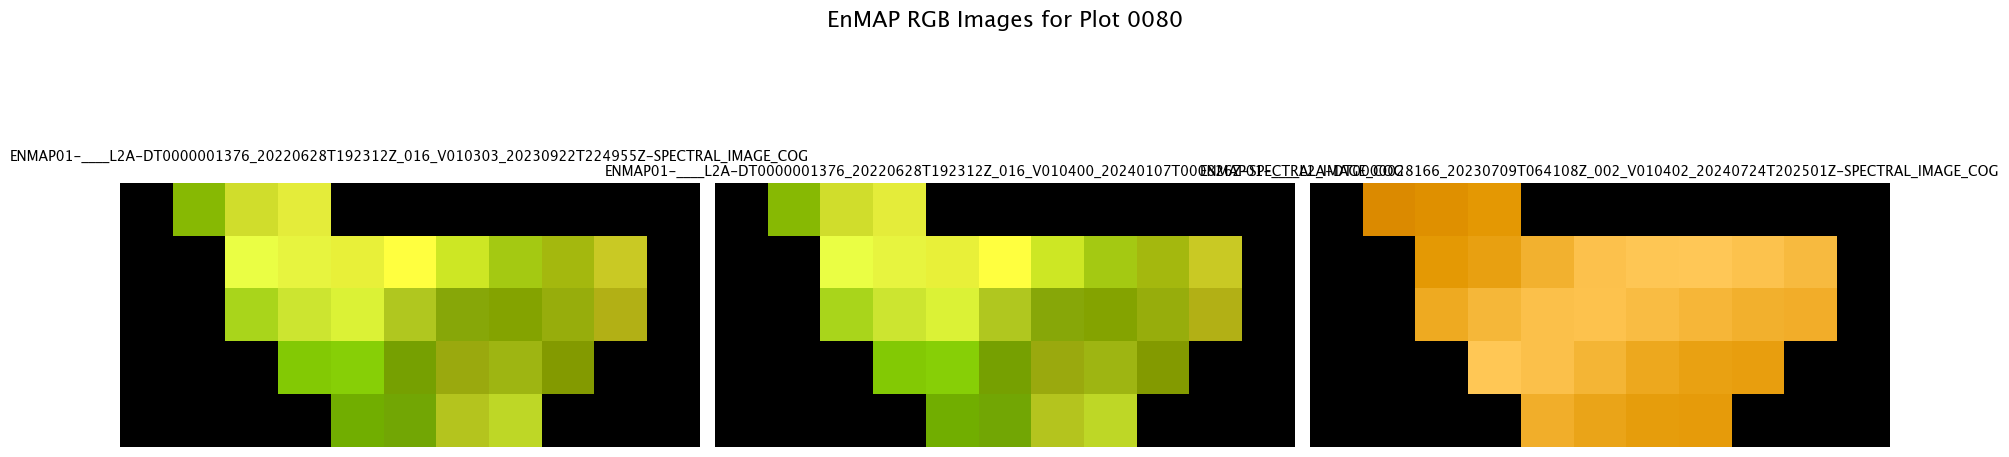

In [5]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

# --- Directory with cropped EnMAP TIFFs ---
tiff_dir = Path("/Users/dangause/Desktop/calacademy/hrs_botany/rs-hsi-botany/notebooks/downloads/enmap_downloads_20250626/0080")
tiff_files = sorted(tiff_dir.glob("*.tiff"))

# --- Stretch function ---
def stretch_rgb(rgb):
    vmin, vmax = np.percentile(rgb[rgb > -32768], [2, 98])
    return np.clip((rgb - vmin) / (vmax - vmin), 0, 1)

# --- Load, stretch, and prepare metadata ---
images = []
extents = []
titles = []

for path in tiff_files:
    with rasterio.open(path) as src:
        # Read RGB bands (adjust if needed)
        rgb = src.read([45, 30, 15])
        transform = src.transform
        height, width = src.height, src.width

        stretched = stretch_rgb(rgb)
        stretched = np.transpose(stretched, (1, 2, 0))  # shape: (H, W, 3)
        images.append(stretched)

        # Compute extent
        xmin = transform.c
        xmax = xmin + transform.a * width
        ymax = transform.f
        ymin = ymax + transform.e * height
        extents.append([xmin, xmax, ymin, ymax])

        # Use stem of filename as title
        titles.append(path.stem)

# --- Plotting ---
n = len(images)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharex=True, sharey=True)

if n == 1:
    axes = [axes]  # Handle single subplot case

for ax, img, extent, title in zip(axes, images, extents, titles):
    ax.imshow(img, extent=extent, origin="upper")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

fig.suptitle("EnMAP RGB Images for Plot 0080", fontsize=16)
plt.tight_layout()
plt.show()
